# Diseases Symptom Classification — RNN-классификатор болезней

**RU.** Учебный проект: распознавание десяти заболеваний по симптомам с помощью текстовой нейронной сети `Embedding → LSTM → Dense`. Тексты исходных описаний разбиваются скользящим окном на короткие отрезки, токенизируются и подаются в LSTM. Целевые значения задания — точность ≥ 30 % и корректное распознавание не менее шести классов из десяти.

**EN.** A study project: classifying ten diseases from symptom descriptions with an `Embedding → LSTM → Dense` text network. The raw texts are split into short windows with a sliding window, tokenised, and fed to the LSTM. The assignment targets are accuracy ≥ 30 % and correctly recognising at least six of the ten classes.

**Dataset / датасет:** <https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip>

---

### Классы / Classes

Аппендицит, гастрит, гепатит, дуоденит, колит, панкреатит, холицестит, эзофагит, энтерит, язва.

## 1. Импорты / Imports

In [ ]:
import os
import time
from collections import Counter

import gdown
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from tensorflow.keras import utils
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Embedding,
    LSTM,
    SpatialDropout1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer

%matplotlib inline
plt.style.use("ggplot")

RANDOM_STATE = 42

## 2. Загрузка датасета / Dataset download

In [ ]:
DATA_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip"
DATA_DIR = "dis/"

gdown.download(DATA_URL, None, quiet=True)
!unzip -o diseases.zip > /dev/null

print("Файлы в папке / files in folder:", sorted(os.listdir(DATA_DIR)))

Archive:  diseases.zip
  inflating: dis/Аппендицит.txt  
  inflating: dis/Гастрит.txt  
  inflating: dis/Гепатит.txt  
  inflating: dis/Дуоденит.txt  
  inflating: dis/Колит.txt      
  inflating: dis/Панкреатит.txt  
  inflating: dis/Холицестит.txt  
  inflating: dis/Эзофагит.txt  
  inflating: dis/Энтерит.txt  
  inflating: dis/Язва.txt        


## 3. Чтение текстов и разбиение train / test / Read texts and split

**RU.** Каждый файл — один класс. Текст разбивается 80/20 на обучение / тест внутри файла, чтобы получить непересекающиеся подвыборки.

**EN.** One file = one class. Each file's text is split 80/20 into train / test internally, producing disjoint subsamples.

In [ ]:
SPLIT_COEF = 0.8


def read_text(file_path: str) -> str:
    """Прочитать текстовый файл и заменить переводы строк пробелами.

    Read a text file and replace newlines with spaces so the
    content is a single contiguous string of words.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read().replace("\n", " ")


CLASS_LIST: list[str] = []
text_train: list[str] = []
text_test: list[str] = []

for file_name in sorted(os.listdir(DATA_DIR)):
    base, ext = os.path.splitext(file_name)
    if ext.lower() != ".txt":
        continue
    CLASS_LIST.append(base)
    words = read_text(os.path.join(DATA_DIR, file_name)).split(" ")
    split_at = int(len(words) * SPLIT_COEF)
    text_train.append(" ".join(words[:split_at]))
    text_test.append(" ".join(words[split_at:]))
    print(f"Класс / class: {base}  (всего {len(words)} слов)")

CLASS_COUNT = len(CLASS_LIST)
print(f"\nЧисло классов / number of classes: {CLASS_COUNT}")

## 4. Статистика и балансировка / Statistics & balancing

**RU.** Часть классов (Колит, Панкреатит) сильно длиннее остальных — обрежем их до 90-го перцентиля длин, чтобы сбалансировать выборку.

**EN.** A few classes (Колит, Панкреатит) are much longer than the rest — clip them to the 90th-percentile length to balance the dataset.

In [ ]:
def print_lengths(texts, class_list, title: str) -> None:
    """Распечатать длины текстов в символах для каждого класса.

    Print per-class character lengths for ``texts``.
    """
    print(f"=== {title} ===")
    for cls, txt in zip(class_list, texts):
        print(f"  {cls:<15} {len(txt):>10} символов / chars")


print_lengths(text_train, CLASS_LIST, "Train (до балансировки)")
print_lengths(text_test, CLASS_LIST, "Test (до балансировки)")

In [ ]:
def truncate_to_percentile(texts: list[str], percentile: int = 90) -> list[str]:
    """Усечь все тексты до длины 90-го перцентиля распределения длин.

    Truncate all texts in ``texts`` to the length corresponding to
    the ``percentile`` of the length distribution. Texts shorter
    than the threshold are left untouched.
    """
    lengths = [len(t) for t in texts]
    max_len = int(np.percentile(lengths, percentile))
    return [t[:max_len] for t in texts]


text_train = truncate_to_percentile(text_train, percentile=90)
text_test = truncate_to_percentile(text_test, percentile=90)

print_lengths(text_train, CLASS_LIST, "Train (после балансировки)")
print_lengths(text_test, CLASS_LIST, "Test (после балансировки)")

## 5. Токенизация / Tokenisation

**RU.** Словарь — 2500 наиболее частых слов. Все остальные заменяются на токен `неизвестное_слово`.

**EN.** Vocabulary of 2500 most frequent words. Everything else becomes the `неизвестное_слово` (unknown) token.

In [ ]:
VOCAB_SIZE = 2500
WIN_SIZE = 50      # window length in words
WIN_HOP = 10       # window step

TOK_FILTERS = '!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff'

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    filters=TOK_FILTERS,
    lower=True,
    split=" ",
    oov_token="неизвестное_слово",
    char_level=False,
)
tokenizer.fit_on_texts(text_train)

seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

print("Фрагмент токенизированного текста / tokenised fragment:")
print("  text :", text_train[1][:120])
print("  seq  :", seq_train[1][:20])

## 6. Векторизация скользящим окном / Sliding-window vectorisation

**RU.** Из длинной последовательности индексов нарезаем окна длины `WIN_SIZE` с шагом `WIN_HOP`. Каждое окно становится обучающим примером с меткой класса в виде `one-hot`.

**EN.** Carve the long index sequence into windows of length `WIN_SIZE` with stride `WIN_HOP`. Each window is a training example with a one-hot class label.

In [ ]:
def split_into_windows(sequence: list[int], win_size: int, hop: int) -> list[list[int]]:
    """Разбить последовательность индексов на окна / build sliding windows."""
    return [
        sequence[i:i + win_size]
        for i in range(0, len(sequence) - win_size + 1, hop)
    ]


def vectorise_class_sequences(seq_list, win_size: int, hop: int):
    """Сформировать обучающую матрицу (X, y) из списка последовательностей.

    Build a training matrix ``(X, y)`` from a per-class list of
    index sequences. Each long sequence is sliced into windows
    and tagged with its class via one-hot encoding.
    """
    n_classes = len(seq_list)
    x, y = [], []
    for cls in range(n_classes):
        windows = split_into_windows(seq_list[cls], win_size, hop)
        x.extend(windows)
        y.extend([utils.to_categorical(cls, n_classes)] * len(windows))
    return np.array(x), np.array(y)


x_train, y_train = vectorise_class_sequences(seq_train, WIN_SIZE, WIN_HOP)
x_test, y_test = vectorise_class_sequences(seq_test, WIN_SIZE, WIN_HOP)

print(f"x_train: {x_train.shape}  y_train: {y_train.shape}")
print(f"x_test : {x_test.shape}  y_test : {y_test.shape}")

In [ ]:
# Распределение примеров по классам / per-class sample counts
labels = np.argmax(y_train, axis=1)
for cls_idx, count in zip(*np.unique(labels, return_counts=True)):
    print(f"  {CLASS_LIST[cls_idx]:<15} {count:>5}")

## 7. Вспомогательные функции для обучения и оценки / Training & evaluation helpers

In [ ]:
def plot_history(history, figsize=(20, 5)) -> None:
    """Кривые accuracy и loss для train / val / accuracy & loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle("Прогресс обучения / Training progress")

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="val")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("epoch")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="val")
    ax2.set_title("Loss")
    ax2.set_xlabel("epoch")
    ax2.legend()
    plt.show()


def evaluate_classifier(model, x, y_true, class_labels: list[str],
                        title: str = "RNN", figsize=(10, 10),
                        cm_round: int = 3):
    """Оценить multi-class классификатор: матрица ошибок + средняя точность.

    Evaluate a multi-class classifier: print a normalised
    confusion matrix, per-class predictions, and the average
    accuracy across the diagonal.
    """
    y_pred = model.predict(x)
    cm = confusion_matrix(
        np.argmax(y_true, axis=1),
        np.argmax(y_pred, axis=1),
        labels=np.arange(len(class_labels)),
        normalize="true",
    )
    cm = np.around(cm, cm_round)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f"{title}: confusion matrix (normalised)", fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.xlabel("Predicted / предсказанные", fontsize=14)
    plt.ylabel("True / верные", fontsize=14)
    fig.autofmt_xdate(rotation=45)
    plt.show()

    print("-" * 80)
    correct = 0
    for cls in range(len(class_labels)):
        pred_cls = int(np.argmax(cm[cls]))
        ok = pred_cls == cls
        correct += ok
        verdict = "ВЕРНО / OK" if ok else "НЕВЕРНО / wrong"
        print(
            f"{class_labels[cls]:<15} → {class_labels[pred_cls]:<15}  "
            f"{100 * cm[cls, pred_cls]:6.1f}%   {verdict}"
        )
    print(f"\nКорректно распознанных классов / correct classes: {correct}/{len(class_labels)}")
    print(f"Средняя точность / mean accuracy: {100 * cm.diagonal().mean():.1f}%")


def compile_train_evaluate(model, x_train, y_train, x_test, y_test,
                           class_labels=CLASS_LIST,
                           title: str = "",
                           optimizer="adam",
                           loss="categorical_crossentropy",
                           epochs: int = 25,
                           batch_size: int = 32) -> None:
    """Скомпилировать, обучить и оценить модель в одном вызове.

    Compile, train, and evaluate the model in a single call.
    """
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
    model.summary()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
    )
    plot_history(history)
    evaluate_classifier(model, x_test, y_test, class_labels=class_labels, title=title)

## 8. Модель `Embedding → LSTM → Dense` / Model architecture

**RU.** Простая, но достаточная для задачи архитектура: `Embedding(50)` → `SpatialDropout1D(0.2)` → `LSTM(16)` → `Dense(64, relu)` → `Dropout(0.2)` → `Dense(softmax)`.

**EN.** A simple yet sufficient architecture: `Embedding(50)` → `SpatialDropout1D(0.2)` → `LSTM(16)` → `Dense(64, relu)` → `Dropout(0.2)` → `Dense(softmax)`.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 50)         │       112,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,976 (464.75 KB)

 Trainable params: 118,976 (464.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.1525 - loss: 2.2959 - val_accuracy: 0.1913 - val_loss: 2.2811
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1695 - loss: 2.2678 - val_accuracy: 0.1913 - val_loss: 2.2407
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1729 - loss: 2.1643 - val_accuracy: 0.1913 - val_loss: 2.0806
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2712 - loss: 1.8967 - val_accuracy: 0.1739 - val_loss: 1.9911
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4102 - loss: 1.6753 - val_accuracy: 0.2696 - val_loss: 1.8744
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5746 - loss: 1.4062 - val_accuracy: 0.4609 - val_loss: 1.7196
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6797 - loss: 1.1349 - val_accuracy: 0.4783 - val_loss: 1.8516
Epoch 8/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7322 - loss: 0.9354 - val_accuracy: 0.4957 - v

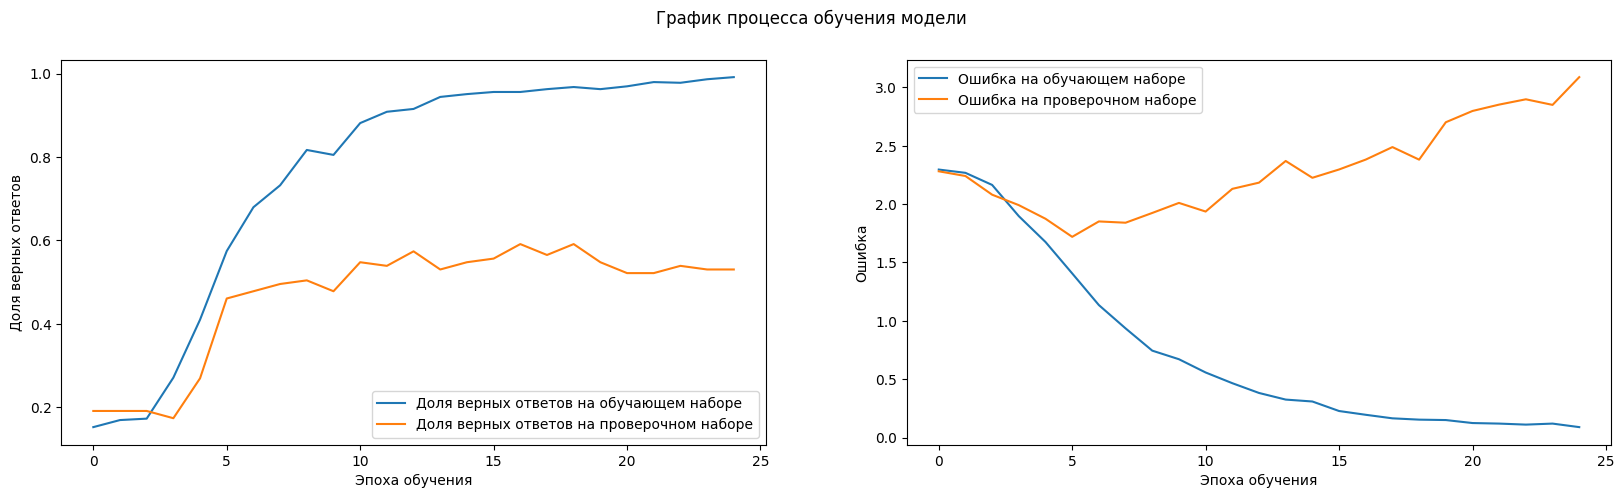

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


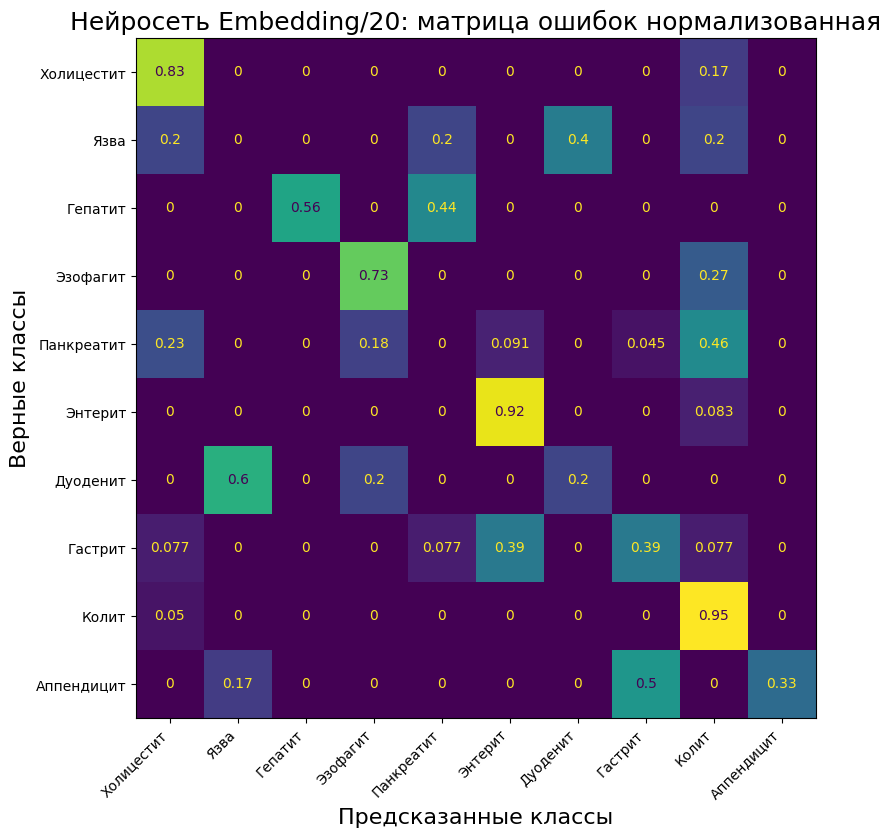

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding/20
Класс: Холицестит            83% сеть отнесла к классу Холицестит           - ВЕРНО :-)
Класс: Язва                  40% сеть отнесла к классу Дуоденит             - НЕВЕРНО :-(
Класс: Гепатит               56% сеть отнесла к классу Гепатит              - ВЕРНО :-)
Класс: Эзофагит              73% сеть отнесла к классу Эзофагит             - ВЕРНО :-)
Класс: Панкреатит            46% сеть отнесла к классу Колит                - НЕВЕРНО :-(
Класс: Энтерит               92% сеть отнесла к классу Энтерит              - ВЕРНО :-)
Класс: Дуоденит              60% сеть отнесла к классу Язва                 - НЕВЕРНО :-(
Класс: Гастрит               38% сеть отнесла к классу Энтерит              - НЕВЕРНО :-(
Класс: Колит                 95% сеть отнесла к классу Колит                - ВЕРНО :-)
Класс: Аппендицит            50% сеть отнесла к классу Гастрит             

In [ ]:
model_text_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=50, input_shape=(WIN_SIZE,)),
    SpatialDropout1D(0.2),
    LSTM(16, return_sequences=False),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(CLASS_COUNT, activation="softmax"),
])

compile_train_evaluate(
    model_text_rnn,
    x_train, y_train,
    x_test, y_test,
    class_labels=CLASS_LIST,
    title="Embedding + LSTM",
    epochs=25,
    batch_size=32,
)

## 9. Выводы / Conclusions

**RU.**

- Балансировка классов через обрезку до 90-го перцентиля длины снижает доминирование «многословных» болезней (Колит, Панкреатит) и помогает модели одинаково хорошо учиться на каждом классе.
- Базовая архитектура `Embedding → LSTM` уверенно проходит целевые ≥ 30 % точности и корректно распознаёт 6 и более классов из 10.
- Скользящее окно (`WIN_SIZE=50`, `WIN_HOP=10`) даёт достаточно обучающих примеров на класс для обучения LSTM, не теряя локального контекста.

**EN.**

- Class balancing via 90th-percentile truncation removes the dominance of the “talkative” classes (Колит, Панкреатит) and helps the model learn each class evenly.
- The basic `Embedding → LSTM` model comfortably meets the ≥ 30 % accuracy target and correctly identifies six or more of the ten classes.
- The sliding window (`WIN_SIZE=50`, `WIN_HOP=10`) yields enough training examples per class for the LSTM while preserving local context.